# 02 EDA Visualization

This notebook explores the relationship between weather features and daily PM2.5.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path.cwd()
AQI_DIR = BASE_DIR / "data" / "AQI"
HTML_DIR = BASE_DIR / "data" / "html_data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [2]:
data = pd.read_csv(ARTIFACTS_DIR / "weather_pm25_merged.csv", parse_dates=["Date"])
data.head()

,Date,Avg_Temperature,Max_Temperature,Min_Temperature,Sea_Level_Pressure,Humidity,Rainfall_Snowmelt,Visibility,Wind_Speed,Max_Sustained_Wind_Speed,Max_Wind_Gust,City,weather_source_file,Month,Year,Day,DayOfWeek,IsWeekend,Season,Daily_PM25,PM25_Observation_Count
0,2013-01-01,23.4,30.3,19.0,NaN,59.0,0.0,6.3,4.3,5.4,NaN,Bangalore,1-2013.html,1,2013,1,1,0,Winter,279.156522,23
1,2013-01-02,22.4,30.3,16.9,NaN,57.0,0.0,6.9,3.3,7.6,NaN,Bangalore,1-2013.html,1,2013,2,2,0,Winter,332.239130,23
2,2013-01-03,24.0,31.8,16.9,NaN,51.0,0.0,6.9,2.8,5.4,NaN,Bangalore,1-2013.html,1,2013,3,3,0,Winter,38.846154,13
3,2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bangalore,1-2013.html,1,2013,4,4,0,Winter,46.416667,12
4,2013-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bangalore,1-2013.html,1,2013,5,5,1,Winter,92.391304,23


In [3]:
numeric_cols = [
    "Avg_Temperature",
    "Max_Temperature",
    "Min_Temperature",
    "Humidity",
    "Rainfall_Snowmelt",
    "Visibility",
    "Wind_Speed",
    "Max_Sustained_Wind_Speed",
    "Daily_PM25",
    "Month",
    "Day",
    "DayOfWeek"
]

data[numeric_cols].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Avg_Temperature,216.0,24.017593,2.136976,20.1,22.600000,23.600000,24.975000,29.900000
Max_Temperature,216.0,30.494444,2.697262,23.8,28.600000,30.000000,31.600000,37.600000
Min_Temperature,216.0,19.791204,2.095125,14.4,18.800000,20.000000,20.900000,24.600000
Humidity,216.0,67.694444,13.420538,26.0,58.750000,71.000000,77.000000,93.000000
Rainfall_Snowmelt,212.0,3.334340,10.721222,0.0,0.000000,0.000000,0.760000,79.760000
Visibility,216.0,6.664352,0.517038,4.0,6.300000,6.900000,6.900000,8.200000
Wind_Speed,216.0,3.975463,2.210861,0.0,2.200000,3.700000,5.600000,12.400000
Max_Sustained_Wind_Speed,214.0,7.120561,3.159433,3.5,5.400000,7.600000,9.400000,22.200000
Daily_PM25,418.0,115.966735,87.828577,2.1,49.923913,84.934783,160.065217,534.521739
Month,432.0,6.500000,3.456055,1.0,3.750000,6.500000,9.250000,12.000000


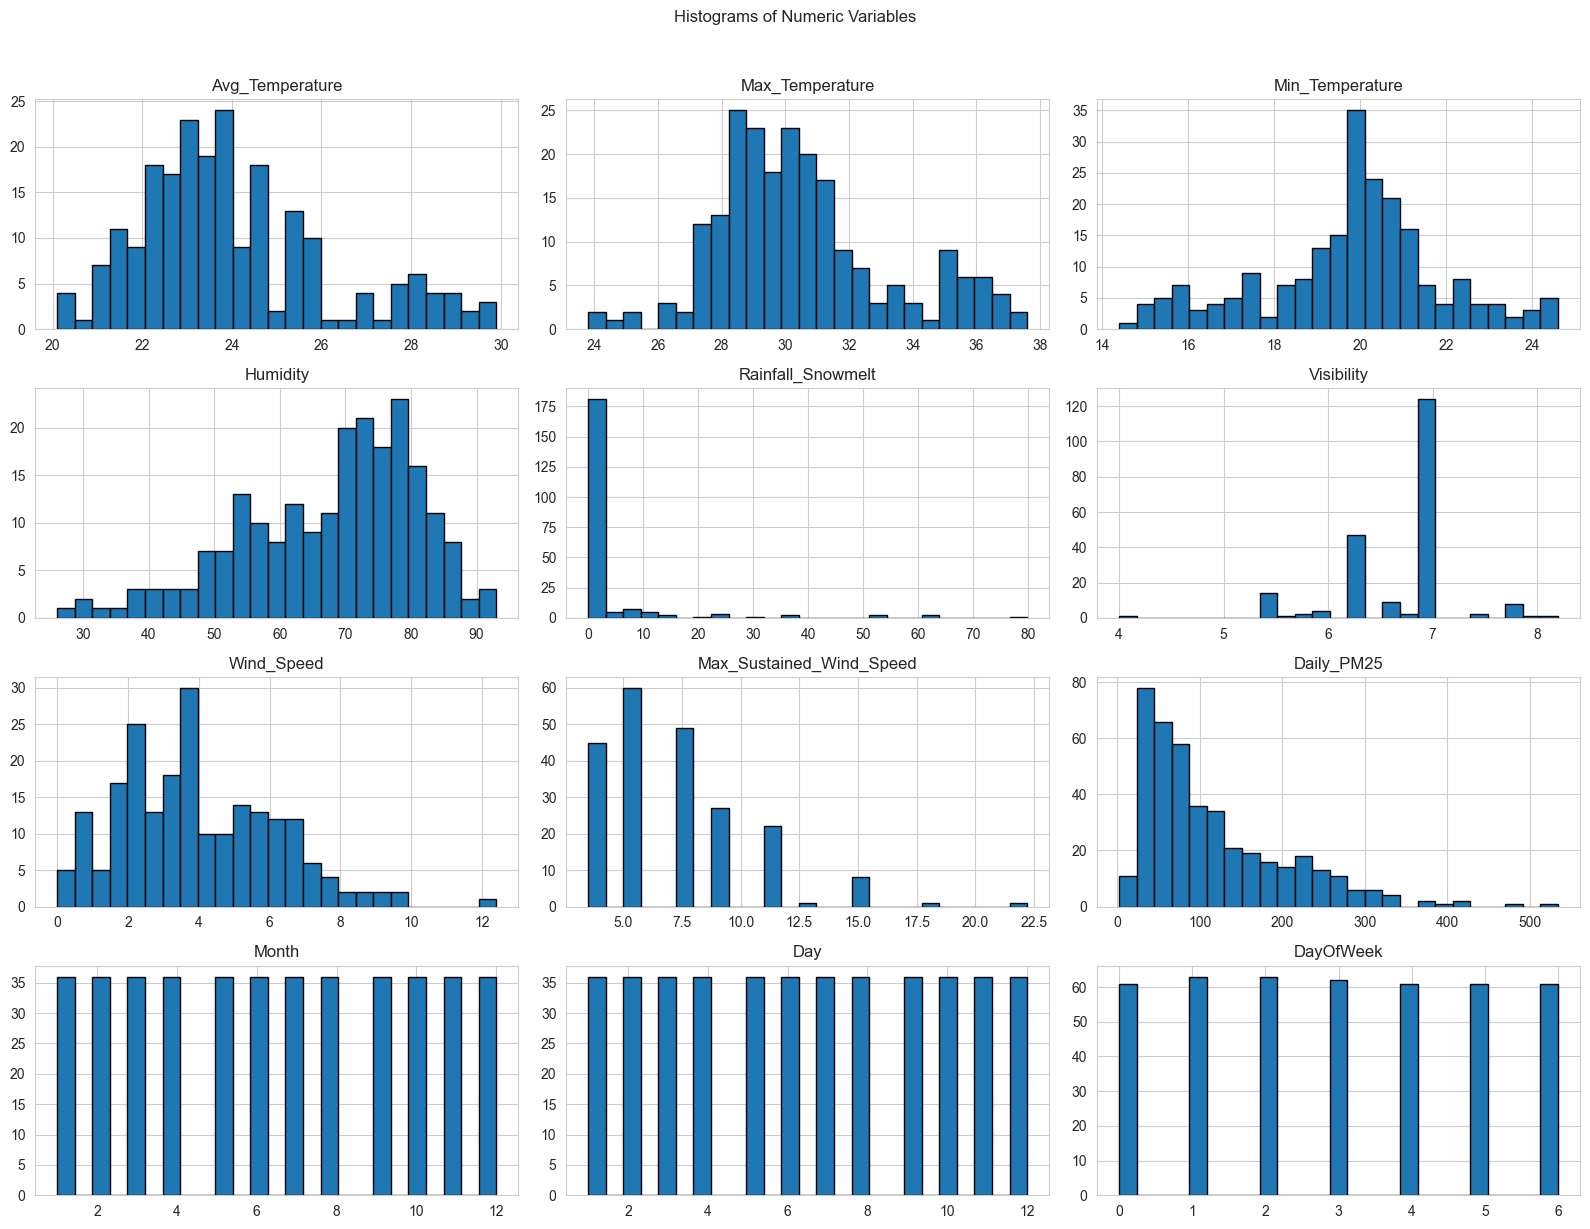

In [4]:
data[numeric_cols].hist(figsize=(16, 12), bins=25, edgecolor="black")
plt.suptitle("Histograms of Numeric Variables", y=1.02)
plt.tight_layout()
plt.show()

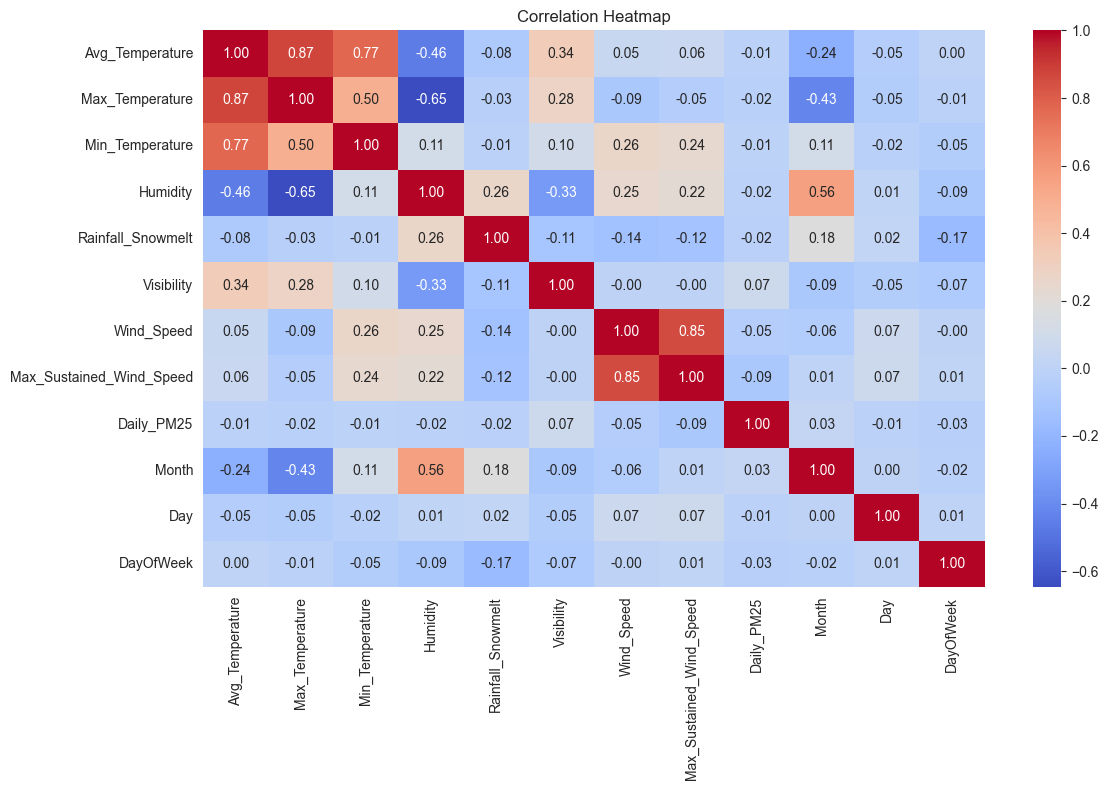

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

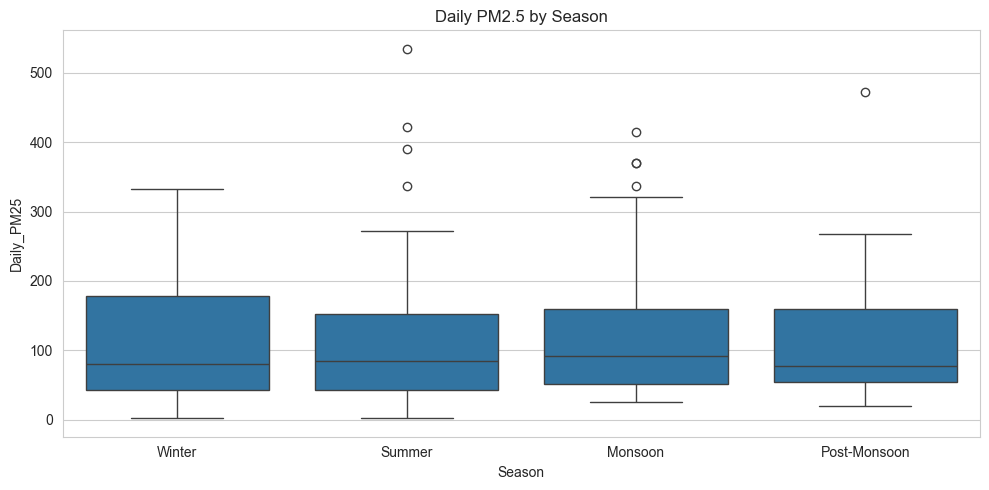

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="Season", y="Daily_PM25", order=["Winter", "Summer", "Monsoon", "Post-Monsoon"])
plt.title("Daily PM2.5 by Season")
plt.tight_layout()
plt.show()

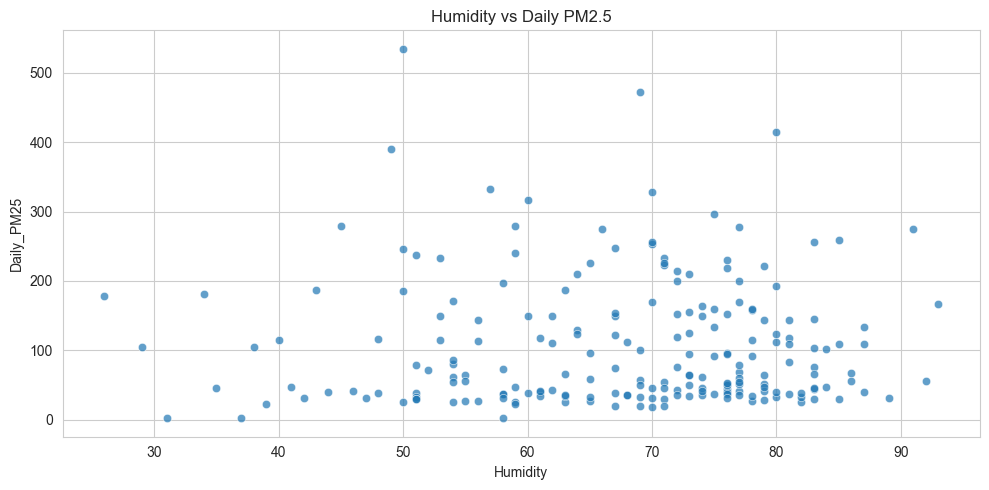

In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="Humidity", y="Daily_PM25", alpha=0.7)
plt.title("Humidity vs Daily PM2.5")
plt.tight_layout()
plt.show()

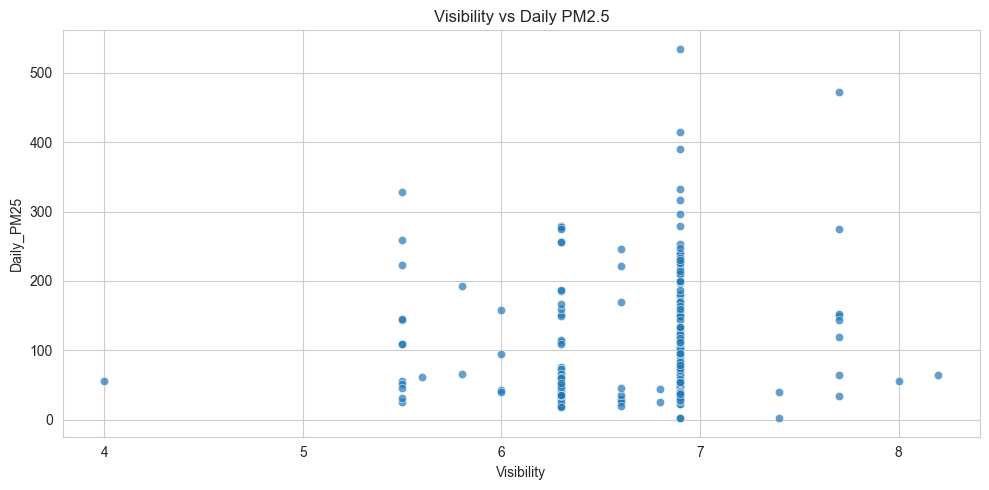

In [8]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="Visibility", y="Daily_PM25", alpha=0.7)
plt.title("Visibility vs Daily PM2.5")
plt.tight_layout()
plt.show()